In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Set plot style
plt.style.use('seaborn-v0_8')

In [2]:
df = pd.read_csv("RELIANCE.NS.csv")

In [3]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2000-01-03,33.917892,35.945827,33.917892,35.945827,26.684866,31204789.0
1,2000-01-04,36.902668,38.823490,35.888702,38.823490,28.821142,66436055.0
2,2000-01-05,36.652744,41.115627,36.652744,40.344440,29.950235,187894923.0
3,2000-01-06,41.272720,42.943623,41.272720,42.036766,31.206556,109810562.0
4,2000-01-07,42.129593,45.399994,41.843967,44.921570,33.348133,139140630.0


In [4]:
df.shape

(6079, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6079 entries, 0 to 6078
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       6079 non-null   object 
 1   Open       6069 non-null   float64
 2   High       6069 non-null   float64
 3   Low        6069 non-null   float64
 4   Close      6069 non-null   float64
 5   Adj Close  6069 non-null   float64
 6   Volume     6069 non-null   float64
dtypes: float64(6), object(1)
memory usage: 332.6+ KB


## Coverting Date Columns to DateTime

In [6]:
df.columns = df.columns.str.strip()

In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)


In [8]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2000-01-03,33.917892,35.945827,33.917892,35.945827,26.684866,31204789.0
1,2000-01-04,36.902668,38.823490,35.888702,38.823490,28.821142,66436055.0
2,2000-01-05,36.652744,41.115627,36.652744,40.344440,29.950235,187894923.0
3,2000-01-06,41.272720,42.943623,41.272720,42.036766,31.206556,109810562.0
4,2000-01-07,42.129593,45.399994,41.843967,44.921570,33.348133,139140630.0


## Checking Missing Values

In [9]:
df.isnull().sum()

Date          0
Open         10
High         10
Low          10
Close        10
Adj Close    10
Volume       10
dtype: int64

In [10]:
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,6079,6069.000000,6069.000000,6069.000000,6069.000000,6069.000000,6.069000e+03
mean,2012-01-17 06:25:52.755387392,689.282224,697.132526,680.887468,688.717071,665.596257,1.759492e+07
min,2000-01-03 00:00:00,29.347902,31.347273,28.155420,29.019436,21.542969,0.000000e+00
25%,2005-11-10 12:00:00,114.392555,116.963173,113.971260,115.435089,100.121124,6.592663e+06
50%,2012-01-05 00:00:00,431.793610,437.051025,425.621887,431.610748,396.301300,1.052491e+07
75%,2018-02-27 12:00:00,852.798096,861.164246,843.151917,851.518066,828.857910,2.120097e+07
max,2024-04-29 00:00:00,3011.550049,3024.899902,2974.449951,3014.800049,3014.800049,3.161448e+08
std,NaN,744.042341,751.140627,736.631838,743.652502,746.829061,1.927247e+07


In [11]:
df.fillna(method='ffill', inplace=True)
df.fillna(method = 'bfill', inplace=True)

C:\Users\Vaishnavi Khasnis\AppData\Local\Temp\ipykernel_2572\3473469831.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users\Vaishnavi Khasnis\AppData\Local\Temp\ipykernel_2572\3473469831.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method = 'bfill', inplace=True)


##  Closing Price Trend(Long-Term)  

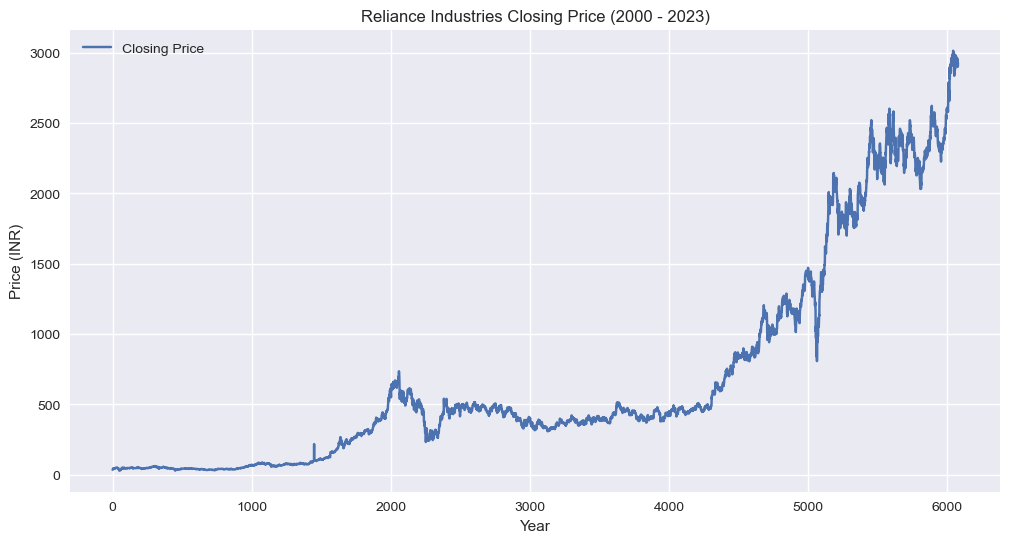

In [12]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Closing Price')
plt.title('Reliance Industries Closing Price (2000 - 2023)')
plt.xlabel('Year')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()

## Short-Term vs Long-Term Trend

In [13]:
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

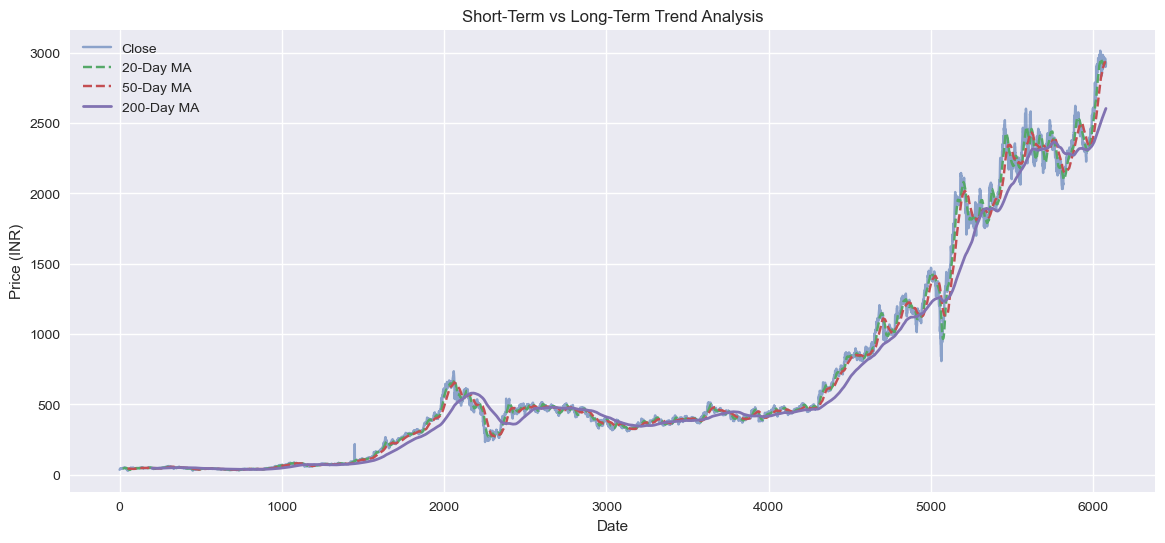

In [14]:
plt.figure(figsize=(14,6))
plt.plot(df['Close'], alpha=0.6, label='Close')
plt.plot(df['MA_20'], label='20-Day MA', linestyle='--')
plt.plot(df['MA_50'], label='50-Day MA', linestyle='--')
plt.plot(df['MA_200'], label='200-Day MA', linewidth=2)
plt.title("Short-Term vs Long-Term Trend Analysis")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.legend()
plt.show()

## Daily Price Volatility

In [15]:
df['Daily_Range'] = df['High'] - df['Low']

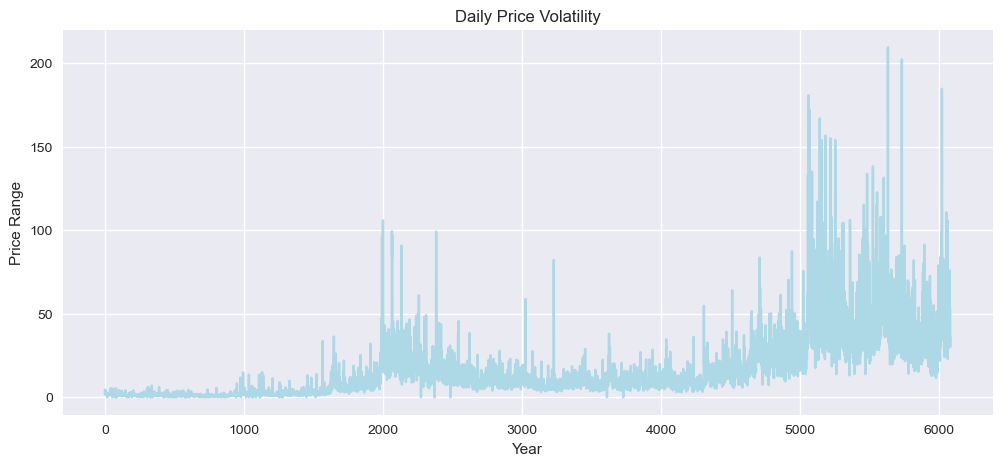

In [16]:
plt.figure(figsize=(12,5))
plt.plot(df['Daily_Range'], color='lightblue')
plt.title("Daily Price Volatility")
plt.xlabel("Year")
plt.ylabel("Price Range")
plt.show()

## Volume Analysis

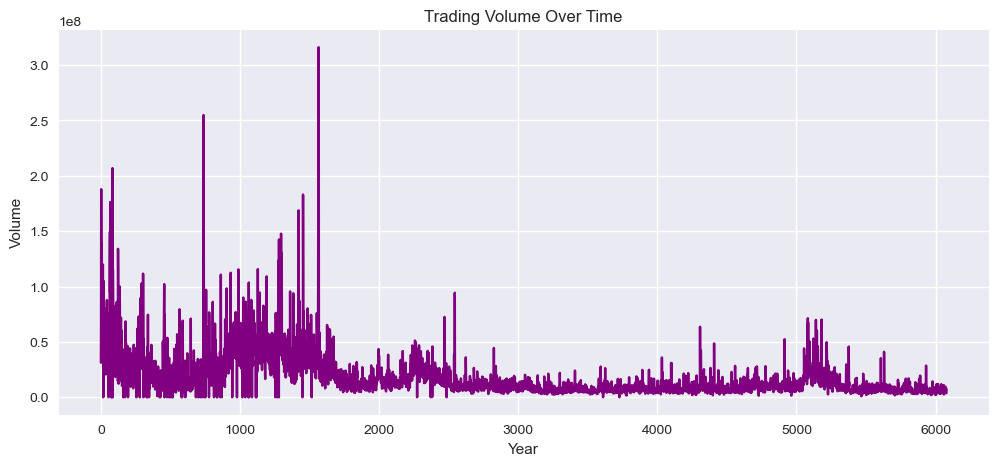

In [17]:
plt.figure(figsize=(12,5))
plt.plot(df['Volume'], color='purple')
plt.title("Trading Volume Over Time")
plt.xlabel("Year")
plt.ylabel("Volume")
plt.show()

## Price vs Volume Reltionship

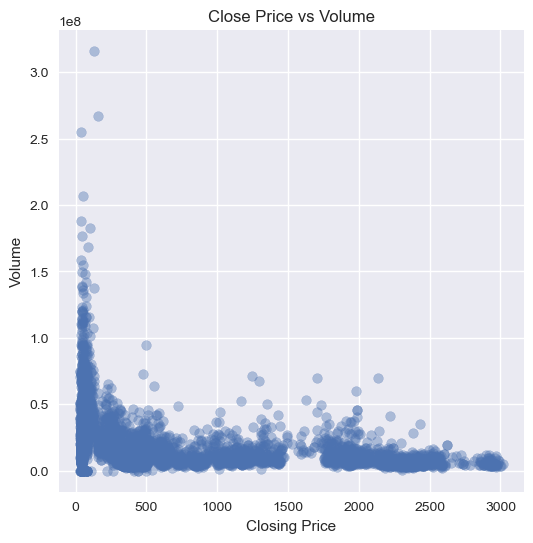

In [18]:
plt.figure(figsize=(6,6))
plt.scatter(df['Close'], df['Volume'], alpha=0.4)
plt.title("Close Price vs Volume")
plt.xlabel("Closing Price")
plt.ylabel("Volume")
plt.show()

## Correlation Analysis

In [19]:
corr_matrix = df[['Open', 'High', 'Low', 'Close', 'Volume']].corr()

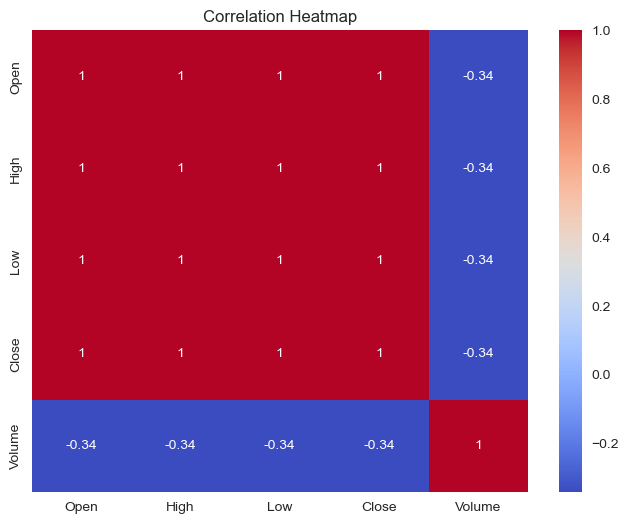

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Distribution of Closing Prices

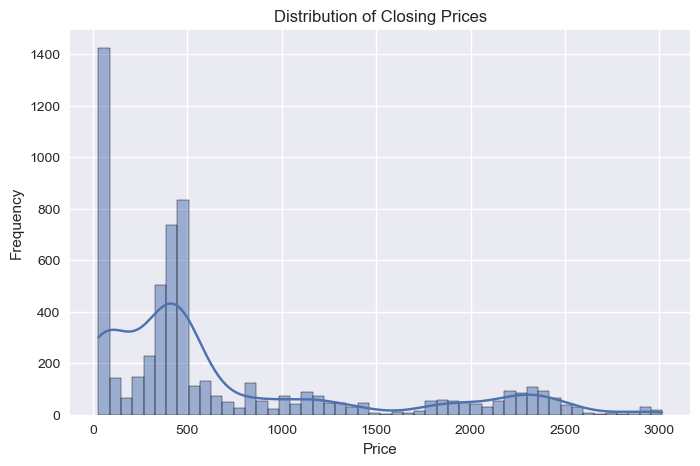

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['Close'], bins=50, kde=True)
plt.title("Distribution of Closing Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

## Outlier Detection

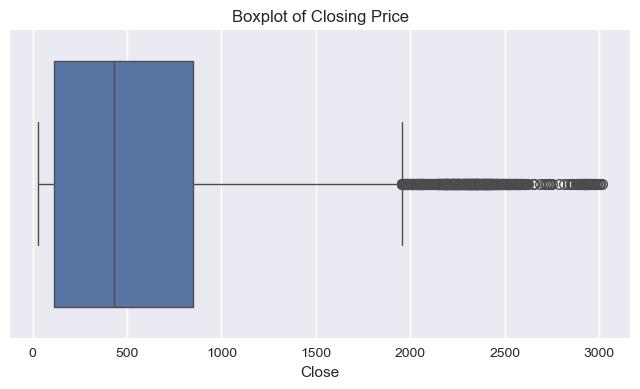

In [22]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Close'])
plt.title("Boxplot of Closing Price")
plt.show()

## Returns Calculation

In [23]:
df['Daily_Return'] = df['Close'].pct_change()

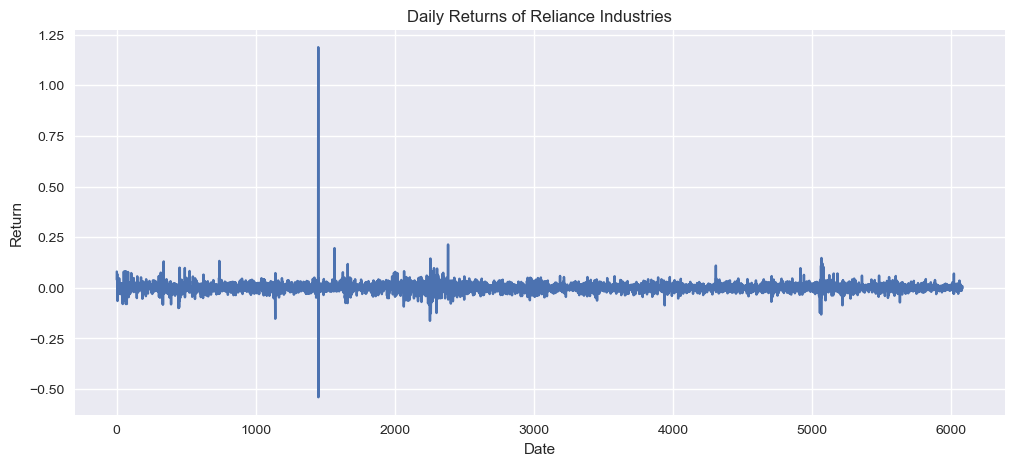

In [24]:
plt.figure(figsize=(12,5))
plt.plot(df['Daily_Return'])
plt.title("Daily Returns of Reliance Industries")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

## Splitting Data

In [25]:
# Last 1 year as test data
train = df[:-252]
test = df[-252:]
print("Training Data Shape:", train.shape)
print("Testing Data Shape:", test.shape)

Training Data Shape: (5827, 12)
Testing Data Shape: (252, 12)


In [26]:
ts = df['Close'].dropna()

## Train-Test-Split

In [27]:
train_ts = ts[:-252]
test_ts = ts[-252:]
print(len(train_ts), len(test_ts))

5827 252


## ARIMA

In [28]:
from statsmodels.tsa.stattools import adfuller
adf = adfuller(train_ts)
print("ADF p-value:", adf[1])

ADF p-value: 0.9842520238016931


## Fit ARIMA only on Train Data

In [29]:
from statsmodels.tsa.arima.model import ARIMA

In [30]:
arima_model = ARIMA(train_ts, order=(5,1,0))
arima_fit = arima_model.fit()
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 5827
Model:                 ARIMA(5, 1, 0)   Log Likelihood              -24464.464
Date:                Tue, 03 Mar 2026   AIC                          48940.928
Time:                        11:33:10   BIC                          48980.948
Sample:                             0   HQIC                         48954.846
                               - 5827                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0176      0.006      2.838      0.005       0.005       0.030
ar.L2          0.0176      0.006      2.922      0.003       0.006       0.029
ar.L3         -0.0503      0.006     -8.467      0.0

## Forecast Test Period

In [31]:
arima_pred = arima_fit.forecast(steps=252)

## ARIMA Evaluation

In [32]:
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

ARIMA RMSE: 443.8251102509531


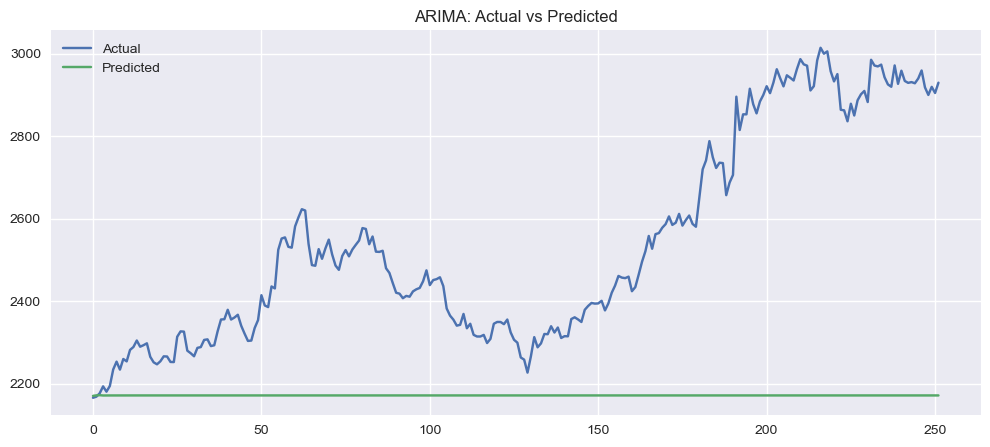

In [33]:
rmse_arima = np.sqrt(mean_squared_error(test_ts, arima_pred))
print("ARIMA RMSE:",rmse_arima)
plt.figure(figsize=(12,5))
plt.plot(test_ts.values, label='Actual')
plt.plot(arima_pred.values, label='Predicted')
plt.title("ARIMA: Actual vs Predicted")
plt.legend()
plt.show()

## Auto-ARIMA

In [34]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima_model = SARIMAX(
    train_ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit()
print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Close   No. Observations:                 5827
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood              -24405.767
Date:                            Tue, 03 Mar 2026   AIC                          48821.534
Time:                                    11:34:01   BIC                          48854.862
Sample:                                         0   HQIC                         48833.128
                                           - 5827                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1546      0.296      0.522      0.602      -0.426       0.735
ma.L1         -0.1352      0.297   

In [35]:
sarima_pred = sarima_fit.forecast(steps=252)

## Evaluate SARIMA

In [36]:
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

SARIMA RMSE: 385.54427266898307


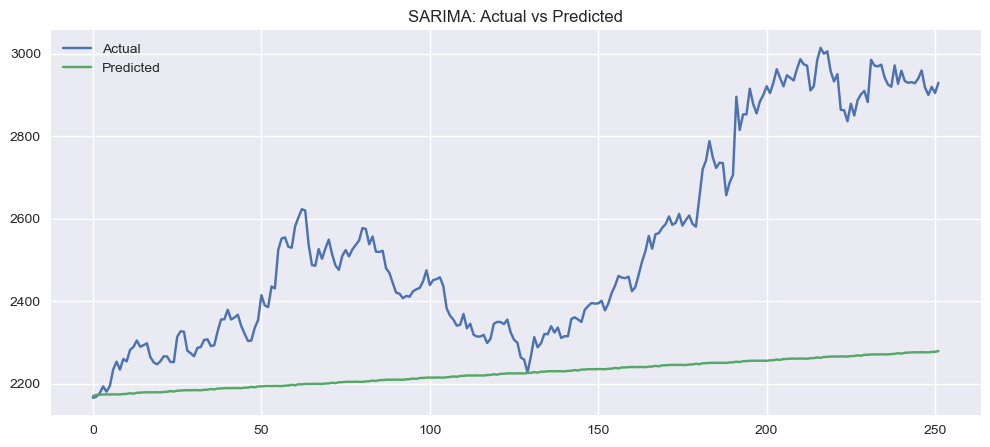

In [37]:
rmse_sarima = np.sqrt(mean_squared_error(test_ts, sarima_pred))
print("SARIMA RMSE:", rmse_sarima)
plt.figure(figsize=(12,5))
plt.plot(test_ts.values, label='Actual')
plt.plot(sarima_pred.values, label='Predicted')
plt.title("SARIMA: Actual vs Predicted")
plt.legend()
plt.show()

## MACHINE LEARNING MODELS

## Create lag feature

In [38]:
df_ml=pd.DataFrame({'Close': ts})
df_ml['Lag1'] = df_ml['Close'].shift(1)
df_ml.dropna(inplace=True)

## Train/Test split

In [39]:
x = df_ml[['Lag1']]
y = df_ml['Close']

x_train = x[:-252]
x_test  = x[-252:]

y_train = y[:-252]
y_test  = y[-252:]

## Linear Regression

In [40]:
from sklearn.linear_model import LinearRegression

In [41]:
lr = LinearRegression()
lr.fit(x_train, y_train)
lr_pred= lr.predict(x_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_pred))
print("Linear REgression RMSE:", rmse_lr)

Linear REgression RMSE: 29.977202353396482


## Random Forest

In [42]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

rf_pred = rf.predict(x_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
print("Random Forest RMSE:", rmse_rf)

Random Forest RMSE: 188.3658604407164


## LSTM - SCALING DONE AFTER SPLIT

## Train/Test split

In [43]:
train_values = train_ts.values.reshape(-1,1)
test_values  = test_ts.values.reshape(-1,1)

## Scaling

In [44]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_values)
test_scaled  = scaler.transform(test_values)

## Creating Sequences

In [45]:
def create_seq(data, step=60):
    x, y = [], []
    for i in range(step, len(data)):
        x.append(data[i-step:i, 0])
        y.append(data[i, 0])
    return np.array(x), np.array(y)

x_train_lstm, y_train_lstm = create_seq(train_scaled)
x_test_lstm,  y_test_lstm  = create_seq(test_scaled)

## LSTM Model

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

x_train_lstm = x_train_lstm.reshape(-1, 60, 1)
x_test_lstm  = x_test_lstm.reshape(-1, 60, 1)

model = Sequential([
    LSTM(50, return_sequences=False, input_shape=(60,1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(x_train_lstm, y_train_lstm, epochs=10, batch_size=32)

C:\Users\Vaishnavi Khasnis\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 0.0048
Epoch 2/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - loss: 1.8423e-04
Epoch 3/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - loss: 1.7436e-04
Epoch 4/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 1.7715e-04
Epoch 5/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 1.5425e-04
Epoch 6/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 1.5130e-04
Epoch 7/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 1.3532e-04
Epoch 8/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - loss: 1.3667e-04
Epoch 9/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 1.3086e-04
Epoch 10/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 1.2057e-04


In [49]:
import joblib
joblib.dump(sarima_model, "sarima_model.pkl", compress=3)

['sarima_model.pkl']